# Pratique de pandas : un exemple complet

Lino Galiana  
2023-12-20

Les exemples de ce TP sont visualisables sous forme de `Jupyter Notebooks`:

Dans cette série d’exercices `Pandas`,
nous allons découvrir comment manipuler plusieurs
jeux de données avec `Python`.

Si vous êtes intéressés par `R`,
une version très proche de ce TP est
disponible dans [ce cours](https://rgeo.linogaliana.fr/exercises/r-wrangling.html).

Dans ce tutoriel, nous allons utiliser deux sources de données :

-   Les émissions de gaz à effet de serre estimées au niveau communal par l’`ADEME`. Le jeu de données est
    disponible sur [data.gouv](https://www.data.gouv.fr/fr/datasets/inventaire-de-gaz-a-effet-de-serre-territorialise/#_)
    et requêtable directement dans `Python` avec
    [cet url](https://koumoul.com/s/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert) (ce sera l’objet du premier exercice).
-   Idéalement, on utiliserait directement les données
    [disponibles sur le site de l’Insee](https://www.insee.fr/fr/statistiques/3560121) mais celles-ci nécessitent un peu de travail
    de nettoyage qui n’entre pas dans le cadre de ce TP.
    Pour faciliter l’import de données Insee, il est recommandé d’utiliser le *package*
    [`pynsee`](https://pynsee.readthedocs.io/en/latest/) qui simplifie l’accès aux données
    de l’Insee disponibles sur le site web [insee.fr](https://www.insee.fr/fr/accueil)
    ou via des API.

La librairie `pynsee` n’est pas installée par défaut avec `Python`. Avant de pouvoir l’utiliser,
il est nécessaire de l’installer :

In [1]:
!pip install xlrd
!pip install pynsee

Toutes les dépendances indispensables étant installées, il suffit
maintenant d’importer les librairies qui seront utilisées
pendant ces exercices :

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynsee
import pynsee.download

## Importer les données

### Import d’un csv de l’Ademe

L’URL d’accès aux données peut être conservé dans une variable *ad hoc* :

In [3]:
url = "https://koumoul.com/s/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert"

L’objectif du premier exercice est de se familiariser à l’import et l’affichage de données
avec `Pandas`.

<div class="alert alert-success" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #3fb618;">
<h3 class="alert-heading"><i class="fa fa-pencil"></i> Exercice 1: Importer un CSV et explorer la structure de données</h3>

1.  Importer les données de l’Ademe à l’aide du package `Pandas` et de la commande consacrée pour l’import de csv. Nommer le `DataFrame` obtenu `emissions`[1].
2.  Utiliser les méthodes adéquates afin d’afficher pour les 10 premières valeurs, les 15 dernières et un échantillon aléatoire de 10 valeurs grâce aux méthodes adéquates du *package* `Pandas`.
3.  Tirer 5 pourcents de l’échantillon sans remise.
4.  Ne conserver que les 10 premières lignes et tirer aléatoirement dans celles-ci pour obtenir un DataFrame de 100 données.
5.  Faire 100 tirages à partir des 6 premières lignes avec une probabilité de 1/2 pour la première observation et une probabilité uniforme pour les autres.

<details>

<summary>

En cas de blocage à la question 1

</summary>

Lire la documentation de `read_csv` (très bien faite) ou chercher des exemples
en ligne pour découvrir cette fonction.

</details>

</div>

[1] Par manque d’imagination, on est souvent tenté d’appeler notre
*dataframe* principal `df` ou `data`. C’est souvent une mauvaise idée puisque
ce nom n’est pas très informatif quand on relit le code quelques semaines
plus tard. L’autodocumentation, approche qui consiste à avoir un code
qui se comprend de lui-même, est une bonne pratique et il est donc recommandé
de donner un nom simple mais efficace pour connaître la nature du *dataset* en question.

## Premières manipulations de données

Le chapitre précédent évoquait quelques manipulations traditionnelles
de données. Les principales sont rappelées ici :

![Sélectionner des colonnes](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/select_pandas.png)
![Renommer des colonnes](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/rename_pandas.png)

![Créer de nouvelles colonnes](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/mutate_pandas.png)
![Sélectionner des lignes](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/filter_pandas.png)

![Réordonner le *DataFrame*](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/arrange_pandas.png)

La *cheatsheet* suivante est très pratique puisqu’elle illustre ces différentes
fonctions. Il est recommandé de régulièrement
la consulter :

![Cheasheet `Pandas`](https://cdn-images-1.medium.com/max/2000/1*YhTbz8b8Svi22wNVvqzneg.jpeg)

L’objectif du prochain exercice est de se familiariser aux principales manipulations de données
sur un sous-ensemble de la table des émissions de gaz carbonique.

<div class="alert alert-success" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #3fb618;">
<h3 class="alert-heading"><i class="fa fa-pencil"></i> Exercice 2: Découverte des verbes de <code>Pandas</code> pour manipuler des données</h3>

En premier lieu, on propose de se familiariser avec les opérations sur
les colonnes.

1.  Créer un *dataframe* `emissions_copy` ne conservant que les colonnes
    `INSEE commune`, `Commune`, `Autres transports` et `Autres transports international`

<details>

<summary>

Indice pour cette question

</summary>

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/select_pandas.png)

</details>

1.  Comme les noms de variables sont peu pratiques, les renommer de la
    manière suivante :
    -   `INSEE commune` $\to$ `code_insee`
    -   `Autres transports` $\to$ `transports`
    -   `Autres transports international` $\to$ `transports_international`

<details>

<summary>

Indice pour cette question

</summary>

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/rename_pandas.png)

</details>

1.  On propose, pour simplifier, de remplacer les valeurs manquantes (`NA`)
    par la valeur 0. Utiliser la
    méthode [`fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
    pour transformer les valeurs manquantes en 0.

2.  Créer les variables suivantes :

    -   `dep`: le département. Celui-ci peut être créé grâce aux deux premiers caractères de `code_insee` en appliquant la méthode `str` ;
    -   `transports_total`: les émissions du secteur transports (somme des deux variables)

<details>

<summary>

Indice pour cette question

</summary>

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/mutate_pandas.png)

</details>

1.  Ordonner les données du plus gros pollueur au plus petit
    puis ordonner les données
    du plus gros pollueur au plus petit par département (du 01 au 95).

<details>

<summary>

Indice pour cette question

</summary>

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/arrange_pandas.png)

</details>

1.  Ne conserver que les communes appartenant aux départements 13 ou 31.
    Ordonner ces communes du plus gros pollueur au plus petit.

<details>

<summary>

Indice pour cette question

</summary>

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/filter_pandas.png)

</details>

1.  Calculer les émissions totales par départements

<details>

<summary>

Indice pour cette question

</summary>

-   *“Grouper par”* = `groupby`
-   *“émissions totales”* = `agg({*** : "sum"})`

</details>

</div>

A la question 5, quand on ordonne les communes exclusivement à partir de la variable
`transports_total`, on obtient ainsi:

A la question 6, on obtient ce classement :

### Import des données de l’Insee

En ce qui concerne nos informations communales, on va utiliser l’une des
sources de l’Insee les plus utilisées : les données [`Filosofi`](https://www.insee.fr/fr/metadonnees/source/serie/s1172).
Afin de faciliter la récupération de celles-ci, nous allons
utiliser le *package* communautaire `pynsee` :

<div class="alert alert-info" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #007bff80;">
<h3 class="alert-heading"><i class="fa fa-comment"></i> Note</h3>

Le *package* `pynsee` comporte deux principaux points d’entrée :

-   Les API de l’Insee, ce qui sera illustré dans le chapitre consacré.
-   Quelques jeux de données directement issus du site web de
    l’Insee ([insee.fr](https://www.insee.fr/fr/accueil))

Dans ce chapitre, nous allons exclusivement utiliser cette deuxième
approche. Cela se fera par le module `pynsee.download`.

La liste des données disponibles depuis ce *package* est [ici](https://inseefrlab.github.io/DoReMIFaSol/articles/donnees_dispo.html).
La fonction `download_file` attend un identifiant unique
pour savoir quelle base de données aller chercher et
restructurer depuis le
site [insee.fr](https://www.insee.fr/fr/accueil).

<details>

<summary>

Connaître la liste des bases disponibles

</summary>

Pour connaître la liste des bases disponibles, vous
pouvez utiliser la fonction `meta = pynsee.get_file_list()`
après avoir fait `import pynsee`.
Celle-ci renvoie un `DataFrame` dans lequel on peut
rechercher, par exemple grâce à une recherche
de mots-clefs :

``` python
meta = pynsee.get_file_list()
meta.loc[meta['label'].str.contains(r"Filosofi.*2016")]
```

    pynsee.download's metadata rely on volunteering contributors and their manual updates
    get_file_list does not provide data from official Insee's metadata API
    Consequently, please report any issue

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>

|     | id                   | name            | label                                             | collection | link                                              | type | zip  | big_zip | data_file                 | tab    | ... | label_col | date_ref   | meta_file | separator | type_col | long_col | val_col | encoding | last_row | missing_value |
|-----|----------------------|-----------------|---------------------------------------------------|------------|---------------------------------------------------|------|------|---------|---------------------------|--------|-----|-----------|------------|-----------|-----------|----------|----------|---------|----------|----------|---------------|
| 79  | FILOSOFI_COM_2016    | FILOSOFI_COM    | Données Filosofi niveau communal – 2016           | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | COM    | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |
| 80  | FILOSOFI_EPCI_2016   | FILOSOFI_EPCI   | Données Filosofi niveau EPCI – 2016               | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | EPCI   | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |
| 81  | FILOSOFI_ARR_2016    | FILOSOFI_ARR    | Données Filosofi niveau arondissement – 2016      | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | ARR    | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |
| 82  | FILOSOFI_DEP_2016    | FILOSOFI_DEP    | Données Filosofi niveau départemental – 2016      | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | DEP    | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |
| 83  | FILOSOFI_REG_2016    | FILOSOFI_REG    | Données Filosofi niveau régional – 2016           | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | REG    | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |
| 84  | FILOSOFI_METRO_2016  | FILOSOFI_METRO  | Données Filosofi niveau France métropolitaine ... | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | METRO  | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |
| 85  | FILOSOFI_AU2010_2016 | FILOSOFI_AU2010 | Données Filosofi niveau aire urbaine – 2016       | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | AU2010 | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |
| 86  | FILOSOFI_UU2010_2016 | FILOSOFI_UU2010 | Données Filosofi niveau unité urbaine – 2016      | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | UU2010 | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |
| 87  | FILOSOFI_ZE2010_2016 | FILOSOFI_ZE2010 | Données Filosofi niveau zone d’emploi – 2016      | FILOSOFI   | https://www.insee.fr/fr/statistiques/fichier/4... | xls  | True | False   | base-cc-filosofi-2016.xls | ZE2010 | ... | NaN       | 2016-01-01 | NaN       | NaN       | NaN      | NaN      | NaN     | NaN      | NaN      | NaN           |

<p>9 rows × 24 columns</p>
</div>

Ici, `meta['label'].str.contains(r"Filosofi.*2016")` signifie:
“*`pandas` trouve moi tous les labels où sont contenus les termes Filosofi et 2016.*”
(`.*` signifiant “*peu m’importe le nombre de mots ou caractères entre*”)

</details>

</div>

On va utiliser les données Filosofi (données de revenus) au niveau communal de 2016.
Ce n’est pas la même année que les données d’émission de CO2, ce n’est donc pas parfaitement rigoureux,
mais cela permettra tout de même d’illustrer
les principales fonctionnalités de `Pandas`

Le point d’entrée principal de la fonction `pynsee` est la fonction `download_file`.

Le code pour télécharger les données est le suivant :

In [10]:
from pynsee.download import download_file
filosofi = download_file("FILOSOFI_COM_2016")

Le *DataFrame* en question a l’aspect suivant :

5 rows × 29 columns

`Pandas` a géré automatiquement les types de variables. Il le fait relativement bien, mais une vérification est toujours utile pour les variables qui ont un statut spécifique.

Pour les variables qui ne sont pas en type `float` alors qu’elles devraient l’être, on modifie leur type.

In [12]:
filosofi.loc[:, filosofi.columns[2:]] = (
  filosofi.loc[:, filosofi.columns[2:]]
  .apply(pd.to_numeric, errors='coerce')
)

Un simple coup d’oeil sur les données
donne une idée assez précise de la manière dont les données sont organisées.
On remarque que certaines variables de `filosofi` semblent avoir beaucoup de valeurs manquantes (secret statistique)
alors que d’autres semblent complètes.
Si on désire exploiter `filosofi`, il faut faire attention à la variable choisie.

Notre objectif à terme va être de relier l’information contenue entre ces
deux jeux de données. En effet, sinon, nous risquons d’être frustré : nous allons
vouloir en savoir plus sur les émissions de gaz carbonique mais seront très
limités dans les possibilités d’analyse sans ajout d’une information annexe
issue de `filosofi`.

## Les indices

Les indices sont des éléments spéciaux d’un `DataFrame` puisqu’ils permettent d’identifier certaines observations.
Il est tout à fait possible d’utiliser plusieurs indices, par exemple si on a des niveaux imbriqués.

Pour le moment, on va prendre comme acquis que les codes communes (dits aussi codes Insee) permettent
d’identifier de manière unique une commune. Un exercice ultérieur permettra de s’en assurer.

`Pandas` propose un système d’indice qui permet d’ordonner les variables mais également de gagner
en efficacité sur certains traitements, comme des recherches d’observations. Le prochain
exercice illustre cette fonctionnalité.

<div class="alert alert-success" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #3fb618;">
<h3 class="alert-heading"><i class="fa fa-pencil"></i> Exercice 3 : Les indices</h3>

On suppose ici qu’on peut se fier aux codes communes. En effet, on a un même ordre de grandeur de communes dans les deux bases.

``` python
print(emissions[['INSEE commune', 'Commune']].nunique())
print(filosofi[['CODGEO', 'LIBGEO']].nunique())
```

    INSEE commune    35798
    Commune          33338
    dtype: int64
    CODGEO    34932
    LIBGEO    32676
    dtype: int64

1.  Fixer comme indice la variable de code commune dans les deux bases.
    Regarder le changement que cela induit sur le *display* du `DataFrame`

2.  Les deux premiers chiffres des codes communes sont le numéro de département.
    Créer une variable de département `dep` dans `emissions` et `filosofi`

3.  Calculer les émissions totales par secteur pour chaque département.
    Mettre en *log* ces résultats dans un objet `emissions_log`.
    Garder 5 départements et produire un `barplot` grâce à la méthode *plot* (la
    figure n’a pas besoin d’être vraiment propre, c’est seulement pour illustrer
    cette méthode)

4.  Repartir de `emissions`.
    Calculer les émissions totales par département et sortir la liste
    des 10 principaux émetteurs de CO2 et des 5 départements les moins émetteurs.
    Essayer de comprendre pourquoi ce sont ces départements qui apparaissent en tête
    du classement. Pour cela, il peut être utile de regarder les caractéristiques de ces
    départements dans `filosofi`

</div>

En pratique, l’utilisation des indices en `Pandas` peut être piégeuse, notamment lorsqu’on
associe des sources de données.  
Il est plutôt recommandé de ne pas les utiliser ou de les utiliser avec parcimonie,
cela pourra éviter de mauvaises surprises.

## Restructurer les données

Quand on a plusieurs informations pour un même individu ou groupe, on
retrouve généralement deux types de structure de données :

-   format **wide** : les données comportent des observations répétées, pour un même individu (ou groupe), dans des colonnes différentes
-   format **long** : les données comportent des observations répétées, pour un même individu, dans des lignes différentes avec une colonne permettant de distinguer les niveaux d’observations

Un exemple de la distinction entre les deux peut être pris à l’ouvrage de référence d’Hadley Wickham, [*R for Data Science*](https://r4ds.hadley.nz/):

![Données *long* et *wide*](https://d33wubrfki0l68.cloudfront.net/3aea19108d39606bbe49981acda07696c0c7fcd8/2de65/images/tidy-9.png)

L’aide mémoire suivante aidera à se rappeler les fonctions à appliquer si besoin :

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/reshape.png)

Le fait de passer d’un format *wide* au format *long* (ou vice-versa)
peut être extrêmement pratique car certaines fonctions sont plus adéquates sur une forme de données ou sur l’autre.

En règle générale, avec `Python` comme avec `R`, les **formats *long* sont souvent préférables**.
Les formats *wide* sont plutôt pensés pour des tableurs comme `Excel` ou on dispose d’un nombre réduit
de lignes à partir duquel faire des tableaux croisés dynamiques.

Le prochain exercice propose donc une telle restructuration de données.
Les données de l’ADEME, et celles de l’Insee également, sont au format
*wide*.
Le prochain exercice illustre l’intérêt de faire la conversion *long* $\to$ *wide*
avant de faire un graphique.

<div class="alert alert-success" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #3fb618;">
<h3 class="alert-heading"><i class="fa fa-pencil"></i> Exercice 5: Restructurer les données : wide to long</h3>

1.  Créer une copie des données de l’`ADEME` en faisant `df_wide = emissions_wide.copy()`

2.  Restructurer les données au format *long* pour avoir des données d’émissions par secteur en gardant comme niveau d’analyse la commune (attention aux autres variables identifiantes).

3.  Faire la somme par secteur et représenter graphiquement

4.  Garder, pour chaque département, le secteur le plus polluant

</div>

## Combiner les données

### Travail préliminaire

Jusqu’à présent lorsque nous avons produit des statistiques descriptives,
celles-ci étaient univariées, c’est-à-dire que nous produisions de l’information
sur une variable mais nous ne la mettions pas en lien avec une autre. Pourtant,
on est rapidement amené à désirer expliquer certaines statistiques agrégées à partir
de caractéristiques issues d’une autre source de données. Cela implique
donc d’associer des jeux de données,
autrement dit de mettre en lien deux jeux de données
présentant le même niveau d’information.

On appelle ceci faire un *merge* ou un *join*. De manière illustrée,
ceci revient à effectuer ce type d’opération :

![](https://pandas.pydata.org/docs/_images/merging_concat_axis1_inner.png)

Avant de faire ceci, il est néanmoins nécessaire de s’assurer que les variables
communes entre les bases de données présentent le bon niveau d’information.

<div class="alert alert-success" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #3fb618;">
<h3 class="alert-heading"><i class="fa fa-pencil"></i> Exercice 6: vérification des clés de jointure</h3>

On commence par vérifier les dimensions des `DataFrames` et la structure de certaines variables clés.
En l’occurrence, les variables fondamentales pour lier nos données sont les variables communales.
Ici, on a deux variables géographiques: un code commune et un nom de commune.

1.  Vérifier les dimensions des *DataFrames*.

2.  Identifier dans `filosofi` les noms de communes qui correspondent à plusieurs codes communes et sélectionner leurs codes. En d’autres termes, identifier les `LIBGEO` tels qu’il existe des doublons de `CODGEO` et les stocker dans un vecteur `x` (conseil: faire attention à l’index de `x`).

On se focalise temporairement sur les observations où le libellé comporte plus de deux codes communes différents

-   *Question 3*. Regarder dans `filosofi` ces observations.

-   *Question 4*. Pour mieux y voir, réordonner la base obtenue par order alphabétique.

-   *Question 5*. Déterminer la taille moyenne (variable nombre de personnes: `NBPERSMENFISC16`) et quelques statistiques descriptives de ces données.
    Comparer aux mêmes statistiques sur les données où libellés et codes communes coïncident.

-   *Question 6*. Vérifier les grandes villes (plus de 100 000 personnes),
    la proportion de villes pour lesquelles un même nom est associé à différents codes commune.

-   *Question 7*. Vérifier dans `filosofi` les villes dont le libellé est égal à Montreuil.
    Vérifier également celles qui contiennent le terme *‘Saint-Denis’*.

</div>

Ce petit exercice permet de se rassurer car les libellés dupliqués
sont en fait des noms de commune identiques mais qui ne sont pas dans le même département.
Il ne s’agit donc pas d’observations dupliquées.
On peut donc se fier aux codes communes, qui eux sont uniques.

### Associer des données

Une information que l’on cherche à obtenir s’obtient de moins en moins à partir d’une unique base de données. Il devient commun de devoir combiner des données issues de sources différentes.

Nous allons ici nous focaliser sur le cas le plus favorable qui est la situation où une information permet d’apparier de manière exacte deux bases de données (autrement nous serions dans une situation, beaucoup plus complexe, d’appariement flou). La situation typique est l’appariement entre deux sources de données selon un identifiant individuel ou un identifiant de code commune, ce qui est notre cas.

Il est recommandé de lire [ce guide assez complet sur la question des jointures avec R](https://www.book.utilitr.org/03_fiches_thematiques/fiche_joindre_donnees) qui donne des recommandations également utiles en `Python`.

Dans le langage courant du statisticien,
on utilise de manière indifférente les termes *merge* ou *join*. Le deuxième terme provient de la syntaxe `SQL`.
Quand on fait du `Pandas`, on utilise plutôt la commande *merge*.

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/pandas_join.png)

<div class="alert alert-success" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #3fb618;">
<h3 class="alert-heading"><i class="fa fa-pencil"></i> Exercice 7: Calculer l'empreinte carbone par habitant</h3>

En premier lieu, on va calculer l’empreinte carbone de chaque commune.

1.  Créer une variable `emissions` qui correspond aux émissions totales d’une commune

2.  Faire une jointure à gauche entre les données d’émissions et les données de cadrage[1].

3.  Calculer l’empreinte carbone (émissions totales / population).

A ce stade nous pourrions avoir envie d’aller vers la modélisation pour essayer d’expliquer
les déterminants de l’empreinte carbone à partir de variables communales.
Une approche inférentielle nécessite néanmoins pour être pertinente de
vérifier en amont des statistiques descriptives.

1.  Sortir un histogramme en niveau puis en log de l’empreinte carbone communale.

Avec une meilleure compréhension de nos données, nous nous rapprochons
de la statistique inférentielle. Néanmoins, nous avons jusqu’à présent
construit des statistiques univariées mais n’avons pas cherché à comprendre
les résultats en regardant le lien avec d’autres variables.
Cela nous amène vers la statistique bivariée, notamment l’analyse des corrélations.
Ce travail est important puisque toute modélisation ultérieure consistera à
raffiner l’analyse des corrélations pour tenir compte des corrélations croisées
entre multiples facteurs. On propose ici de faire cette analyse
de manière minimale.

1.  Regarder la corrélation entre les variables de cadrage et l’empreinte carbone. Certaines variables semblent-elles pouvoir potentiellement influer sur l’empreinte carbone ?

</div>

[1] Idéalement, il serait nécessaire de s’assurer que cette jointure n’introduit
pas de biais. En effet, comme nos années de référence ne sont pas forcément identiques,
il peut y avoir un *mismatch* entre nos deux sources. Le TP étant déjà long, nous n’allons pas dans cette voie.
Les lecteurs intéressés pourront effectuer une telle analyse en exercice supplémentaire.

A l’issue de la question 5, le graphique des corrélations est le suivant :

<Axes: ylabel='index'>

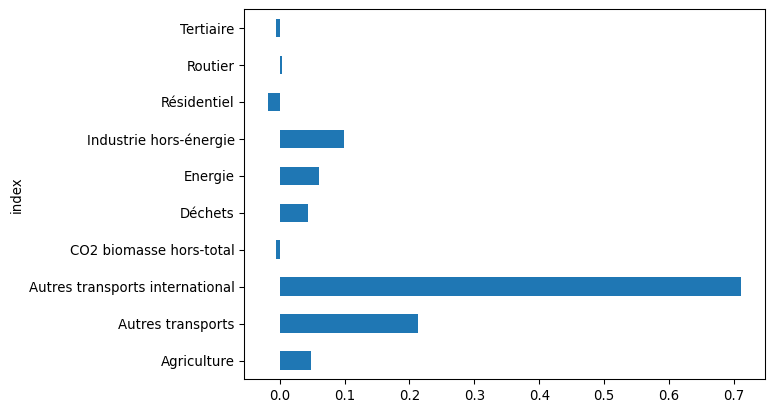

## Exercices bonus

Les plus rapides d’entre vous sont invités à aller un peu plus loin en s’entraînant avec des exercices bonus qui proviennent du [site de Xavier Dupré](http://www.xavierdupre.fr/app/ensae_teaching_cs/helpsphinx3). 3 notebooks en lien avec `numpy` et `pandas` vous y sont proposés :

1.  Calcul Matriciel, Optimisation : [énoncé](http://www.xavierdupre.fr/app/ensae_teaching_cs/helpsphinx3/notebooks/td2a_cenonce_session_2A.html) / [corrigé](http://www.xavierdupre.fr/app/ensae_teaching_cs/helpsphinx3/notebooks/td2a_correction_session_2A.html)
2.  DataFrame et Graphes : [énoncé](http://www.xavierdupre.fr/app/ensae_teaching_cs/helpsphinx3/notebooks/td2a_cenonce_session_1.html) / [corrigé](http://www.xavierdupre.fr/app/ensae_teaching_cs/helpsphinx3/notebooks/td2a_correction_session_1.html)
3.  Pandas et itérateurs : [énoncé](http://www.xavierdupre.fr/app/ensae_teaching_cs/helpsphinx3/notebooks/pandas_iterator.html) / [corrigé](http://www.xavierdupre.fr/app/ensae_teaching_cs/helpsphinx3/notebooks/pandas_iterator_correction.html)